In [2]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split, StratifiedShuffleSplit, StratifiedGroupKFold
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.feature_extraction import FeatureHasher
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import cross_val_score
from sklearn.metrics import precision_recall_curve
from sklearn.ensemble import RandomForestRegressor
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.svm import SVR
from xgboost import XGBRegressor
from columnTransform import AddDropFeatures, to_string_func
from datetime import date
import joblib
import json
import os

In [3]:
df = pd.read_csv("pre-owned cars.csv")

In [4]:
df.head()

,brand,model,transmission,make_year,reg_year,fuel_type,engine_capacity(CC),km_driven,ownership,price,overall_cost,has_insurance,spare_key,reg_number,title
0,Mahindra,Thar LX D 4WD MT CONVERTIBLE,Manual,2020.0,01-01-2021,Diesel,2184.0,11003.0,1st owner,1231000,23431.0,True,No,HR26,2020 Mahindra Thar LX D 4WD MT CONVERTIBLE
1,Hyundai,Verna 1.6 VTVT SX,Manual,2018.0,01-07-2018,Petrol,1591.0,66936.0,1st owner,786000,15359.0,True,No,DL7C,2018 Hyundai Verna 1.6 VTVT SX
2,Tata,Harrier XT PLUS 2.0L KRYOTEC DARK EDITON,Manual,2022.0,01-08-2022,Diesel,1956.0,27990.0,1st owner,1489000,28349.0,True,No,HR29,2022 Tata Harrier XT PLUS 2.0L KRYOTEC DARK ED...
3,Honda,City 1.5L I-VTE V CVT,Automatic,2023.0,01-04-2023,Petrol,1498.0,5061.0,1st owner,1227000,23355.0,True,Yes,DL4C,2023 Honda City 1.5L I-VTE V CVT
4,Ford,Ecosport TITANIUM 1.5L DIESEL,Manual,2021.0,01-07-2021,Diesel,1498.0,23480.0,1st owner,887000,16883.0,True,No,UP14,2021 Ford Ecosport TITANIUM 1.5L DIESEL


In [5]:
df.shape

(2806, 15)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2806 entries, 0 to 2805
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   brand                2805 non-null   object 
 1   model                2805 non-null   object 
 2   transmission         2805 non-null   object 
 3   make_year            2805 non-null   float64
 4   reg_year             720 non-null    object 
 5   fuel_type            2805 non-null   object 
 6   engine_capacity(CC)  2688 non-null   float64
 7   km_driven            2805 non-null   float64
 8   ownership            2805 non-null   object 
 9   price                2806 non-null   int64  
 10  overall_cost         2805 non-null   float64
 11  has_insurance        2805 non-null   object 
 12  spare_key            2805 non-null   object 
 13  reg_number           2805 non-null   object 
 14  title                2805 non-null   object 
dtypes: float64(4), int64(1), object(10)
me

In [7]:
df.describe()

,make_year,engine_capacity(CC),km_driven,price,overall_cost
count,2805.000000,2688.000000,2805.000000,2.806000e+03,2805.000000
mean,2018.181105,1259.027530,49215.477362,1.342522e+06,13495.022816
std,2.945293,254.504798,26626.932696,3.554669e+07,6040.809220
min,2010.000000,624.000000,450.000000,1.630000e+05,4039.000000
25%,2016.000000,1194.000000,28540.000000,4.350000e+05,9267.000000
50%,2018.000000,1197.000000,45695.000000,5.940000e+05,12145.000000
75%,2021.000000,1462.000000,68182.000000,8.140000e+05,15760.000000
max,2024.000000,2694.000000,143991.000000,1.883558e+09,47338.000000


In [8]:
missing_percent = df.isna().sum() / len(df) * 100
missing_data = pd.DataFrame({"missinf value count": df.isna().sum(), "missing percent": missing_percent})
missing_data.sort_values(by="missing percent", ascending=False)

,missinf value count,missing percent
reg_year,2086,74.340699
engine_capacity(CC),118,4.205274
brand,1,0.035638
model,1,0.035638
transmission,1,0.035638
make_year,1,0.035638
fuel_type,1,0.035638
km_driven,1,0.035638
ownership,1,0.035638
overall_cost,1,0.035638


In [9]:
print(df[df["title"].isna()])

     brand model transmission  make_year reg_year fuel_type  \
2805   NaN   NaN          NaN        NaN      NaN       NaN   

      engine_capacity(CC)  km_driven ownership       price  overall_cost  \
2805                  NaN        NaN       NaN  1883558000           NaN   

     has_insurance spare_key reg_number title  
2805           NaN       NaN        NaN   NaN  


In [10]:
print(df.iloc[2805])

brand                         NaN
model                         NaN
transmission                  NaN
make_year                     NaN
reg_year                      NaN
fuel_type                     NaN
engine_capacity(CC)           NaN
km_driven                     NaN
ownership                     NaN
price                  1883558000
overall_cost                  NaN
has_insurance                 NaN
spare_key                     NaN
reg_number                    NaN
title                         NaN
Name: 2805, dtype: object


In [11]:
sup_prices = df["price"].iloc[:2805].sum()

In [12]:
sup_prices

1883558000

In [13]:
df_clean = df.drop(index=2805, axis=0)

In [14]:
df_clean.shape

(2805, 15)

In [15]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2805 entries, 0 to 2804
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   brand                2805 non-null   object 
 1   model                2805 non-null   object 
 2   transmission         2805 non-null   object 
 3   make_year            2805 non-null   float64
 4   reg_year             720 non-null    object 
 5   fuel_type            2805 non-null   object 
 6   engine_capacity(CC)  2688 non-null   float64
 7   km_driven            2805 non-null   float64
 8   ownership            2805 non-null   object 
 9   price                2805 non-null   int64  
 10  overall_cost         2805 non-null   float64
 11  has_insurance        2805 non-null   object 
 12  spare_key            2805 non-null   object 
 13  reg_number           2805 non-null   object 
 14  title                2805 non-null   object 
dtypes: float64(4), int64(1), object(10)
me

In [16]:
df_year = pd.DataFrame({'make_year': df['make_year'], "reg_year": pd.to_numeric(df["reg_year"].str[-4:], errors='coerce')})

In [17]:
df_year.head()

,make_year,reg_year
0,2020.0,2021.0
1,2018.0,2018.0
2,2022.0,2022.0
3,2023.0,2023.0
4,2021.0,2021.0


In [18]:
df_year.shape

(2806, 2)

In [19]:
df_year["make_year"].corr(df_year["reg_year"])

0.9946266707693698

In [20]:
df_year= df_year.dropna()

In [21]:
df_year.shape

(720, 2)

In [22]:
df_year["make_year"].corr(df_year["reg_year"])

0.9946266707693698

In [23]:
df.groupby('brand')['reg_year'].apply(lambda x: x.isna().mean()).sort_values()

brand
Jeep          0.500000
Mahindra      0.657895
Nissan        0.657895
Ford          0.687500
MG            0.702703
Tata          0.716667
Honda         0.728261
KIA           0.732759
Maruti        0.732973
Datsun        0.735294
Toyota        0.750000
Renault       0.772455
Hyundai       0.780303
Volkswagen    0.849057
Skoda         0.969697
Name: reg_year, dtype: float64

In [24]:
corr_matrix = df.select_dtypes(include="number").corr()
print(corr_matrix["price"].sort_values(ascending=False))

price                  1.000000
overall_cost           0.966033
make_year              0.598748
engine_capacity(CC)    0.591982
km_driven             -0.293768
Name: price, dtype: float64


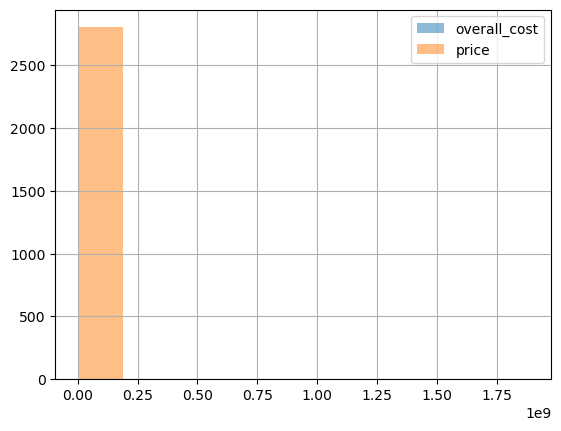

In [25]:
df['overall_cost'].hist(alpha=0.5, label='overall_cost')
df['price'].hist(alpha=0.5, label='price')
plt.legend()
plt.show()

In [26]:
df_clean['ratio'] = df['overall_cost'] / df['price']
print(df_clean['ratio'].describe())

df_clean['diff'] = df['overall_cost'] - df['price']
print(df_clean['diff'].describe())

count    2805.000000
mean        0.020899
std         0.005206
min         0.019024
25%         0.019043
50%         0.019550
75%         0.019561
max         0.088908
Name: ratio, dtype: float64
count    2.805000e+03
mean    -6.580052e+05
std      3.253470e+05
min     -2.439662e+06
25%     -7.975250e+05
50%     -5.823780e+05
75%     -4.264960e+05
max     -1.553360e+05
Name: diff, dtype: float64


In [27]:
y = df_clean['price']
X = df_clean[['overall_cost']]

reg = LinearRegression().fit(X, y)

print("Coefficient:", reg.coef_[0], "Intercept:", reg.intercept_)
print("R^2:", reg.score(X, y))


Coefficient: 52.96138017095611 Intercept: -43214.85554193007
R^2: 0.933218961356874


In [28]:
# Create a temporary flag for missingness
missing_mask = df_clean['engine_capacity(CC)'].isna()

# Compare the mean price of cars with and without missing engine capacity
print(df_clean.loc[missing_mask, 'price'].mean())
print(df_clean.loc[~missing_mask, 'price'].mean())

# Compare the mean make_year
print(df_clean.loc[missing_mask, 'make_year'].mean())
print(df_clean.loc[~missing_mask, 'make_year'].mean())

702521.3675213675
670149.9255952381
2018.7008547008547
2018.158482142857


In [29]:
df_clean["engine_capacity(CC)"] = df_clean["engine_capacity(CC)"].replace(np.nan, "unknown")

In [30]:
df_clean.groupby("engine_capacity(CC)").agg(
    count = ("engine_capacity(CC)", "count"),
    price = ("price", "mean")
)

,count,price
engine_capacity(CC),,
624.0,1,2.400000e+05
796.0,43,3.178140e+05
799.0,26,3.031538e+05
814.0,17,2.720588e+05
998.0,348,5.248017e+05
999.0,176,5.852841e+05
1047.0,1,3.990000e+05
1086.0,54,4.401667e+05
1120.0,3,3.576667e+05


In [31]:
# Check if a specific brand has more unknown engine values
print(df_clean[df_clean['engine_capacity(CC)'] == 'unknown']['brand'].value_counts())

brand
Maruti        29
Hyundai       20
Tata          17
Renault       14
Honda          8
KIA            6
Mahindra       5
Ford           5
Volkswagen     5
Datsun         2
Skoda          2
MG             2
Toyota         1
Jeep           1
Name: count, dtype: int64


In [32]:
df_clean['engine_capacity(CC)'] = pd.to_numeric(df_clean['engine_capacity(CC)'], errors='coerce')
brand_median_engine = df_clean.groupby('brand')['engine_capacity(CC)'].median()
print(brand_median_engine[['Maruti', 'Hyundai', 'Tata', 'Renault', 'Honda']])

brand
Maruti     1197.0
Hyundai    1197.0
Tata       1199.0
Renault     999.0
Honda      1497.0
Name: engine_capacity(CC), dtype: float64


In [33]:
def impute_engine_capacity(row):
    if pd.isna(row['engine_capacity(CC)']): 
        return brand_median_engine[row['brand']]
    else:
        return row['engine_capacity(CC)']

df_clean['engine_capacity(CC)'] = df_clean.apply(impute_engine_capacity, axis=1)

In [34]:
drop_list = ["reg_year", "overall_cost"]
df_clean = df_clean.drop(drop_list, axis=1)

In [35]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2805 entries, 0 to 2804
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   brand                2805 non-null   object 
 1   model                2805 non-null   object 
 2   transmission         2805 non-null   object 
 3   make_year            2805 non-null   float64
 4   fuel_type            2805 non-null   object 
 5   engine_capacity(CC)  2805 non-null   float64
 6   km_driven            2805 non-null   float64
 7   ownership            2805 non-null   object 
 8   price                2805 non-null   int64  
 9   has_insurance        2805 non-null   object 
 10  spare_key            2805 non-null   object 
 11  reg_number           2805 non-null   object 
 12  title                2805 non-null   object 
 13  ratio                2805 non-null   float64
 14  diff                 2805 non-null   float64
dtypes: float64(5), int64(1), object(9)
mem

In [36]:
df_clean = df_clean.drop(["ratio", "diff"], axis=1)

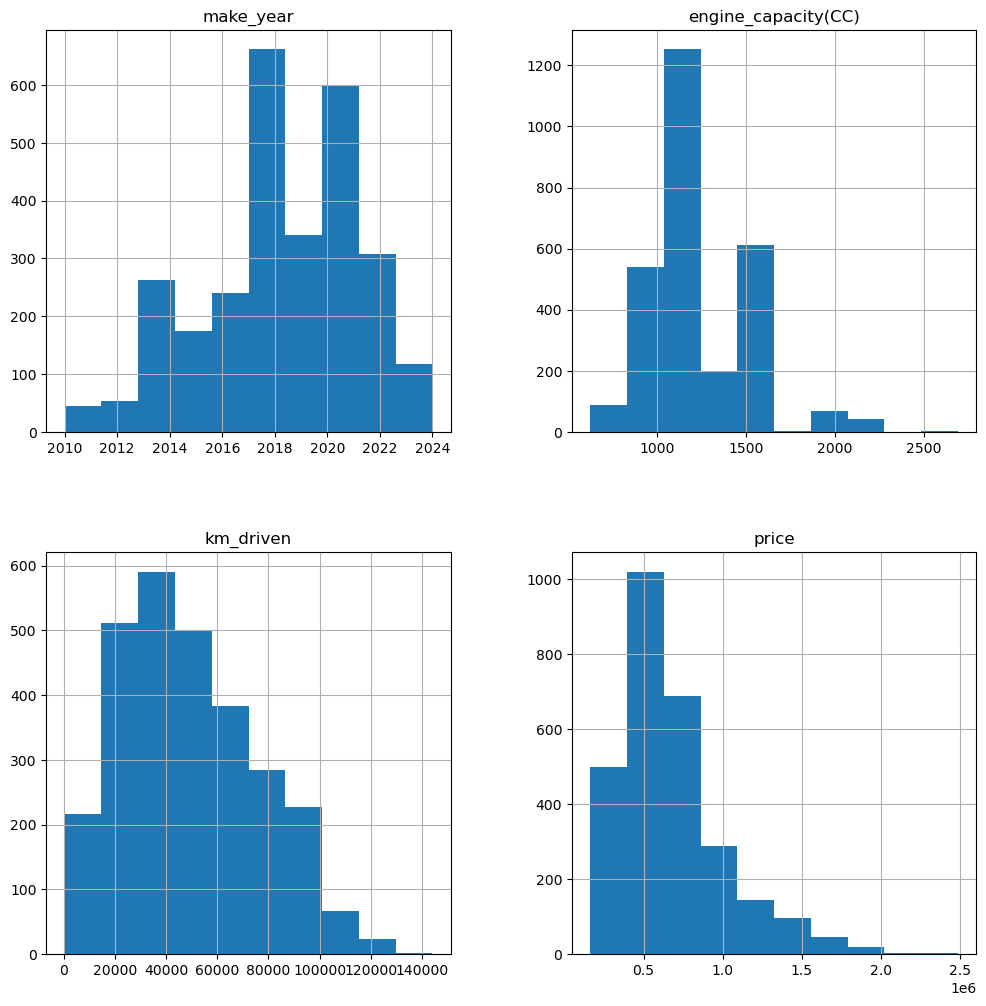

In [37]:
df_clean.select_dtypes(include=["int64", "float64"]).hist(figsize=(12, 12))
plt.grid(True)
plt.show()

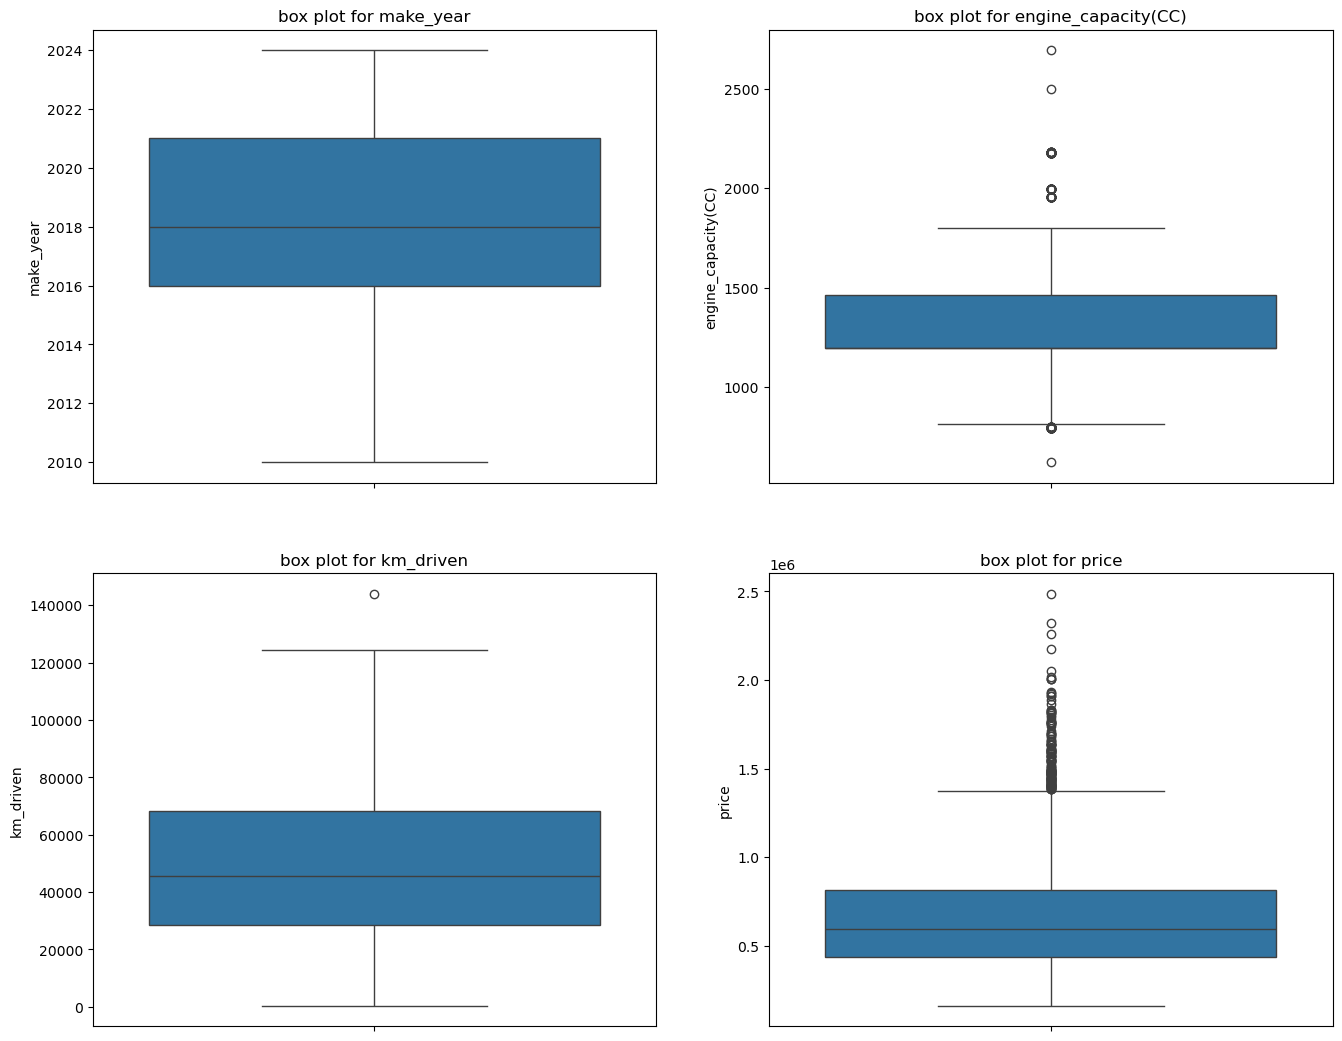

In [38]:
plt.figure(figsize=(16,20))
num_cols = df_clean.select_dtypes(include="number").columns
n_cols = 3  
n_rows = int(np.ceil(len(num_cols) / n_cols))
for i in range(len(num_cols)):
    plt.subplot(n_cols,n_rows,i+1)
    sns.boxplot(y=num_cols[i], data=df_clean)
    plt.title(f"box plot for {num_cols[i]}")
    plt.xticks(rotation=45)
    
plt.show()

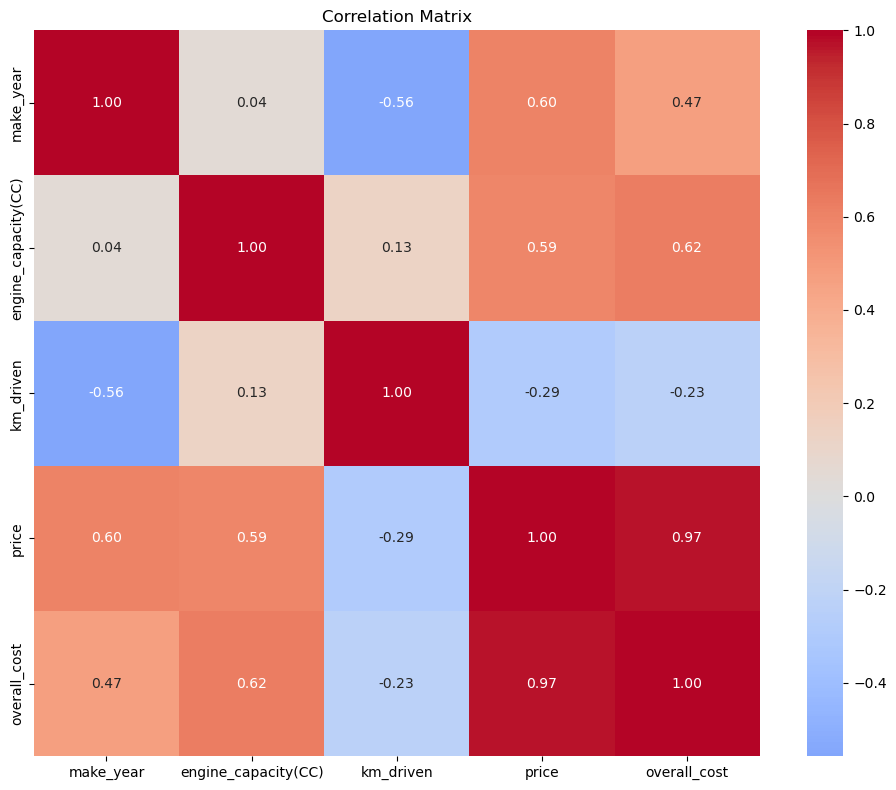

In [39]:
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, 
            annot=True,        
            cmap='coolwarm',   
            center=0,          
            square=True,      
            fmt='.2f')         
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

In [39]:
high_price_cars = df_clean[df_clean['price'] > df_clean['price'].quantile(0.99)]
high_price_cars[['brand', 'model' ,'make_year', 'engine_capacity(CC)', 'fuel_type', 'km_driven', 'price']]


,brand,model,make_year,engine_capacity(CC),fuel_type,km_driven,price
8,Mahindra,XUV700 AX 7 LUXURY D AWD AT 7 STR,2022.0,2184.0,Diesel,62567.0,2322000
253,Tata,Harrier XZA PLUS 2.0L,2022.0,1956.0,Diesel,27222.0,1765000
696,MG,HECTOR SAVVY PRO 1.5 TURBO CVT PETROL,2023.0,1451.0,Petrol,30857.0,2004000
708,Toyota,Innova Crysta 2.7 VX 7 STR,2022.0,2694.0,Petrol,21296.0,2051000
712,Tata,Safari XZA PLUS GOLD 6 S,2021.0,1956.0,Diesel,62380.0,1864000
729,Mahindra,XUV700 AX 7 LUXURY P AT 7 STR,2023.0,1997.0,Petrol,11330.0,2487000
801,Tata,Harrier XZA PLUS 2.0L DUAL TONE,2022.0,1956.0,Diesel,32613.0,1816000
856,Hyundai,Creta SX (O) 1.4 TURBO DCT,2022.0,1353.0,Petrol,20634.0,1777000
963,Tata,Safari XZA PLUS DARK EDITION,2022.0,1956.0,Diesel,15681.0,2173000
967,MG,HECTOR SHARP PRO 1.5 TURBO MT PETROL,2023.0,1451.0,Petrol,15940.0,1825000


In [40]:
high_price_cars.groupby("model").agg(
    count = ("model", "count"),
    price = ("price", "mean")
)

,count,price
model,,
ALCAZAR 2.0 SIGNATURE (O) AT 7STR,1,1889000.0
Creta SX (O) 1.4 TURBO DCT,1,1777000.0
Creta SX (O) 1.4 TURBO DCT DUAL TONE,1,1766000.0
HECTOR PLUS SELECT 2.0 DIESEL TURBO MT 7-STR,1,2016000.0
HECTOR SAVVY PRO 1.5 TURBO CVT PETROL,1,2004000.0
HECTOR SHARP PRO 1.5 PETROL TURBO CVT PETROL,1,1818000.0
HECTOR SHARP PRO 1.5 TURBO MT PETROL,1,1825000.0
Harrier XZA PLUS 2.0L,1,1765000.0
Harrier XZA PLUS 2.0L DARK EDITION,1,1822000.0


In [41]:
df_clean.groupby("model").agg(
    count = ("model", "count"),
    price = ("price", "mean")
)

,count,price
model,,
A Star LXI,1,1.910000e+05
A Star VXI,1,2.800000e+05
ALCAZAR 2.0 SIGNATURE (O) AT 7STR,1,1.889000e+06
ALTROZ XE PETROL,3,5.473333e+05
ALTROZ XT PETROL,1,5.900000e+05
...,...,...
i20 MAGNA (O) 1.2,4,2.965000e+05
i20 MAGNA 1.2,3,2.176667e+05
i20 SPORTZ (O) 1.2,1,2.970000e+05


In [42]:
for col in df_clean.select_dtypes(include="object").columns:
    print(f"{col}: {df_clean[col].nunique()}")

brand: 15
model: 818
transmission: 2
fuel_type: 4
ownership: 3
has_insurance: 1
spare_key: 2
reg_number: 157
title: 1530


In [43]:
for col in df_clean.select_dtypes(include="number").columns:
    print(f"{col}: {df_clean[col].nunique()}")

make_year: 15
engine_capacity(CC): 45
km_driven: 2761
price: 1023


In [44]:
df_clean.describe()

,make_year,engine_capacity(CC),km_driven,price
count,2805.000000,2805.000000,2805.000000,2.805000e+03
mean,2018.181105,1259.500178,49215.477362,6.715002e+05
std,2.945293,253.338883,26626.932696,3.311789e+05
min,2010.000000,624.000000,450.000000,1.630000e+05
25%,2016.000000,1197.000000,28540.000000,4.350000e+05
50%,2018.000000,1197.000000,45695.000000,5.940000e+05
75%,2021.000000,1462.000000,68182.000000,8.140000e+05
max,2024.000000,2694.000000,143991.000000,2.487000e+06


In [45]:
df = df.drop(index=2805)

In [46]:
df["cars_price_cat"] = pd.qcut(df["price"], q=4)

In [47]:
def split_data(data, test_size=0.2, stratify_col=None, random_state=42):
    if stratify_col:
        strat_split = StratifiedShuffleSplit(n_splits=1, test_size=test_size, random_state=random_state)
        for train_idx, test_idx in strat_split.split(data, data[stratify_col]):
            return data.iloc[train_idx], data.iloc[test_idx]
    else:
        return train_test_split(data, test_size=test_size, random_state=random_state)

In [48]:
train_set, test_set = split_data(df, stratify_col="cars_price_cat")

In [49]:
train_set = train_set.drop("cars_price_cat", axis=1)
test_set = test_set.drop("cars_price_cat", axis=1)

In [50]:
train_set.shape

(2244, 15)

In [51]:
test_set.shape

(561, 15)

In [52]:
x_train = train_set.drop("price", axis=1)
y_train = train_set["price"]

x_test = test_set.drop("price", axis=1)
y_test = test_set["price"]

In [53]:
#stage1 pipeline: features engeniring
drop_columns = ["overall_cost", "reg_year", "title"]
stage1_pipeline= Pipeline([
    ('change', AddDropFeatures(drop_columns)),
])
x_stage1 = stage1_pipeline.fit_transform(x_train)
print(f"Stage 1 columns: {list(x_stage1.columns)}")

Stage 1 columns: ['brand', 'model', 'transmission', 'make_year', 'fuel_type', 'engine_capacity(CC)', 'km_driven', 'ownership', 'has_insurance', 'spare_key', 'reg_number', 'age']


In [54]:
num_pipeline = Pipeline([
 ('std_scaler', StandardScaler()),
 ])

cat_pipeline = Pipeline([
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

high_card_attribs = ['model', 'reg_number']
num_attribs = x_stage1.select_dtypes(exclude="object").columns.tolist()
cats = x_stage1.select_dtypes(include="object").columns.tolist()
cat_attribs = [cat for cat in cats if cat not in high_card_attribs]



hash_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),  
    ('to_string', FunctionTransformer(to_string_func)),  
    ('hasher', FeatureHasher(n_features=32, input_type='string')),
])


preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_pipeline, num_attribs),
        ('cat', cat_pipeline, cat_attribs),
        ("high_cat", hash_pipeline, high_card_attribs),
    ],
    remainder='passthrough'
)
X_train_prepared  = preprocessor.fit_transform(x_stage1)

In [55]:
X_train_prepared.shape

(2244, 63)

In [56]:
lin_reg = LinearRegression()
lin_reg.fit(X_train_prepared, y_train)

LinearRegression()

In [57]:
y_prediction= lin_reg.predict(X_train_prepared)
linear_mse = mean_squared_error (y_train, y_prediction)
linear_rmse = np.sqrt(linear_mse)
print("RMSE:", linear_rmse)

RMSE: 147516.55666647194


In [58]:
#test cross validation
scores = cross_val_score(lin_reg, X_train_prepared, y_train, scoring="neg_mean_squared_error", cv=5)
linear_rmse_scores = np.sqrt(-scores)

print(f"cross validation rmse score: {linear_rmse_scores}")
print("Mean RMSE:", linear_rmse_scores.mean())
print("Standard deviation:", linear_rmse_scores.std())

cross validation rmse score: [152498.0088315  147976.44054435 142859.38540174 157970.74844913
 156363.15724759]
Mean RMSE: 151533.54809486354
Standard deviation: 5542.32749003955


In [59]:
y_pred_train = lin_reg.predict(X_train_prepared)
linear_r2 = r2_score(y_train, y_pred_train)
print("Train R²:", linear_r2)

Train R²: 0.8028091149190326


In [60]:
r2_scores = cross_val_score(lin_reg, X_train_prepared, y_train, 
                            scoring="r2", cv=5)

print("Cross-validation R² scores:", r2_scores)
print("Mean R²:", r2_scores.mean())
print("Standard deviation:", r2_scores.std())

Cross-validation R² scores: [0.78279467 0.78166316 0.81278025 0.79830063 0.77730419]
Mean R²: 0.7905685808263901
Standard deviation: 0.013182013617603065


In [61]:
ridge_reg = Ridge(random_state=42)
ridge_reg.fit(X_train_prepared, y_train)

Ridge(random_state=42)

In [62]:
y_prediction = ridge_reg.predict(X_train_prepared)
ridge_mse = mean_squared_error (y_train, y_prediction)
ridge_rmse = np.sqrt(ridge_mse)
print("RMSE:", ridge_rmse)

RMSE: 147546.79753394783


In [63]:
# Test cross validation
scores = cross_val_score(ridge_reg, X_train_prepared, y_train, scoring="neg_mean_squared_error", cv=5)
ridge_rmse_scores = np.sqrt(-scores)

print(f"Cross validation RMSE score: {ridge_rmse_scores}")
print("Mean RMSE:", ridge_rmse_scores.mean())
print("Standard deviation:", ridge_rmse_scores.std())

Cross validation RMSE score: [152552.06927368 147978.7432237  143226.18455584 157676.05872803
 155687.04466929]
Mean RMSE: 151424.02009010717
Standard deviation: 5246.109049314066


In [64]:
y_pred_train = ridge_reg.predict(X_train_prepared)
ridge_r2 = r2_score(y_train, y_pred_train)
print("Train R²:", ridge_r2)

Train R²: 0.8027282584404404


In [65]:
r2_scores = cross_val_score(ridge_reg, X_train_prepared, y_train, 
                            scoring="r2", cv=5)

print("Cross-validation R² scores:", r2_scores)
print("Mean R²:", r2_scores.mean())
print("Standard deviation:", r2_scores.std())

Cross-validation R² scores: [0.78264064 0.78165636 0.81181763 0.79905246 0.7792259 ]
Mean R²: 0.7908785973523751
Standard deviation: 0.012601221917234463


In [66]:
lasso_reg = Lasso(max_iter=5000, random_state=42)
lasso_reg.fit(X_train_prepared, y_train)

Lasso(max_iter=5000, random_state=42)

In [67]:
y_prediction = lasso_reg.predict(X_train_prepared)
lasso_mse = mean_squared_error (y_train, y_prediction)
lasso_rmse = np.sqrt(linear_mse)
print("RMSE:", lasso_rmse)

RMSE: 147516.55666647194


In [68]:
#test cross validation
scores = cross_val_score(lasso_reg, X_train_prepared, y_train, scoring="neg_mean_squared_error", cv=5)
lasso_rmse_scores = np.sqrt(-scores)

print(f"cross validation rmse score: {lasso_rmse_scores}")
print("Mean RMSE:", lasso_rmse_scores.mean())
print("Standard deviation:", lasso_rmse_scores.std())

cross validation rmse score: [152497.42571865 147975.62269182 142863.33355919 157966.12521887
 156352.51818223]
Mean RMSE: 151531.005074151
Standard deviation: 5538.248859815662


In [69]:
y_pred_train = lasso_reg.predict(X_train_prepared)
lasso_r2 = r2_score(y_train, y_pred_train)
print("Train R²:", lasso_r2)

Train R²: 0.8028090936641066


In [70]:
r2_scores = cross_val_score(lasso_reg, X_train_prepared, y_train, 
                            scoring="r2", cv=5)

print("Cross-validation R² scores:", r2_scores)
print("Mean R²:", r2_scores.mean())
print("Standard deviation:", r2_scores.std())

Cross-validation R² scores: [0.78279633 0.78166557 0.81276991 0.79831244 0.7773345 ]
Mean R²: 0.7905757479676218
Standard deviation: 0.013173294612830738


In [71]:
cat_pipeline = Pipeline([
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

high_card_attribs = ['model', 'reg_number']
cats = x_stage1.select_dtypes(include="object").columns.tolist()
cat_attribs = [cat for cat in cats if cat not in high_card_attribs]


hash_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),  
    ('to_string', FunctionTransformer(to_string_func)),  
    ('hasher', FeatureHasher(n_features=32, input_type='string')),
])


preprocessor_tree = ColumnTransformer(
    transformers=[
        ('cat', cat_pipeline, cat_attribs),
        ("high_cat", hash_pipeline, high_card_attribs),
    ],
    remainder='passthrough'
)
X_train_prepared_tree  = preprocessor.fit_transform(x_stage1)

In [72]:
forest_regressor = RandomForestRegressor(random_state=42)
forest_regressor.fit(X_train_prepared_tree, y_train)

RandomForestRegressor(random_state=42)

In [73]:
y_prediction = forest_regressor.predict(X_train_prepared_tree)
forest_mse = mean_squared_error (y_train, y_prediction)
forest_rmse = np.sqrt(linear_mse)
print("RMSE:", forest_rmse)

RMSE: 147516.55666647194


In [74]:
#test cross validation
scores = cross_val_score(forest_regressor, X_train_prepared_tree, y_train, scoring="neg_mean_squared_error", cv=5)
forest_rmse_scores = np.sqrt(-scores)

print(f"cross validation rmse score: {forest_rmse_scores}")
print("Mean RMSE:", forest_rmse_scores.mean())
print("Standard deviation:", forest_rmse_scores.std())

cross validation rmse score: [113884.10125913 106154.51655944  98315.33861913 117824.28140799
 113449.81149051]
Mean RMSE: 109925.60986724093
Standard deviation: 6920.956674918293


In [75]:
y_pred_train = forest_regressor.predict(X_train_prepared_tree)
forest_r2 = r2_score(y_train, y_pred_train)
print("Train R²:", forest_r2)

Train R²: 0.9857273687357595


In [76]:
r2_scores = cross_val_score(forest_regressor, X_train_prepared_tree, y_train, 
                            scoring="r2", cv=5)

print("Cross-validation R² scores:", r2_scores)
print("Mean R²:", r2_scores.mean())
print("Standard deviation:", r2_scores.std())

Cross-validation R² scores: [0.87886536 0.88763816 0.91133001 0.88779279 0.88276677]
Mean R²: 0.8896786187001966
Standard deviation: 0.011324334448184667


In [77]:
xgb_reg = XGBRegressor(random_state=42)
xgb_reg.fit(X_train_prepared_tree, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=None, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=None, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=None, n_jobs=None,
             num_parallel_tree=None, random_state=42, ...)

In [78]:
y_prediction = xgb_reg.predict(X_train_prepared_tree)
xgb_mse = mean_squared_error (y_train, y_prediction)
xgb_rmse = np.sqrt(linear_mse)
print("RMSE:", xgb_rmse)

RMSE: 147516.55666647194


In [79]:
#test cross validation
scores = cross_val_score(xgb_reg, X_train_prepared_tree, y_train, scoring="neg_mean_squared_error", cv=5)
xgb_rmse_scores = np.sqrt(-scores)

print(f"cross validation rmse score: {xgb_rmse_scores}")
print("Mean RMSE:", xgb_rmse_scores.mean())
print("Standard deviation:", xgb_rmse_scores.std())

cross validation rmse score: [109186.57866397 100211.33250335 101657.78411851 117906.998607
 116846.02087788]
Mean RMSE: 109161.74295414213
Standard deviation: 7374.923537228913


In [80]:
y_pred_train = xgb_reg.predict(X_train_prepared_tree)
xgb_r2 = r2_score(y_train, y_pred_train)
print("Train R²:", xgb_r2)

Train R²: 0.9902563914983731


In [81]:
r2_scores = cross_val_score(xgb_reg, X_train_prepared_tree, y_train, 
                            scoring="r2", cv=5)

print("Cross-validation R² scores:", r2_scores)
print("Mean R²:", r2_scores.mean())
print("Standard deviation:", r2_scores.std())

Cross-validation R² scores: [0.88865245 0.89986739 0.90519846 0.88763518 0.87564277]
Mean R²: 0.8913992517316303
Standard deviation: 0.01031607844307987


In [82]:
param_rnd = {
    "max_depth": [2, 3, 4],           
    "min_child_weight": [1, 3],       
    "gamma": [0, 0.1],                
    "subsample": [0.8, 0.9],          
    "colsample_bytree": [0.8, 0.9],   
    "learning_rate": [0.05, 0.1],     
    "n_estimators": [100, 200]        
}
rnd_search = RandomizedSearchCV(xgb_reg, param_distributions=param_rnd,
                                n_iter=20, cv=5,
                                scoring='neg_mean_squared_error',
                                n_jobs=-1, random_state=42)
rnd_search.fit(X_train_prepared, y_train)

RandomizedSearchCV(cv=5,
                   estimator=XGBRegressor(base_score=None, booster=None,
                                          callbacks=None,
                                          colsample_bylevel=None,
                                          colsample_bynode=None,
                                          colsample_bytree=None, device=None,
                                          early_stopping_rounds=None,
                                          enable_categorical=False,
                                          eval_metric=None, feature_types=None,
                                          gamma=None, grow_policy=None,
                                          importance_type=None,
                                          interaction_constraints=None,
                                          learning_rate=...
                                          monotone_constraints=None,
                                          multi_strategy=None,
                                          n_estimators=None, n_jobs=None,
                                          num_parallel_tree=None,
                                          random_state=42, ...),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'colsample_bytree': [0.8, 0.9],
                                        'gamma': [0, 0.1],
                                        'learning_rate': [0.05, 0.1],
                                        'max_depth': [2, 3, 4],
                                        'min_child_weight': [1, 3],
                                        'n_estimators': [100, 200],
                                        'subsample': [0.8, 0.9]},
                   random_state=42, scoring='neg_mean_squared_error')

In [83]:
best_model = rnd_search.best_estimator_

In [84]:
final_pipeline = Pipeline([
    ('stage1', stage1_pipeline),
    ('stage2', preprocessor_tree),
    ('model', best_model)
])

In [85]:
final_pipeline.fit(x_train, y_train)

Pipeline(steps=[('stage1',
                 Pipeline(steps=[('change',
                                  AddDropFeatures(features_to_drop=['overall_cost',
                                                                    'reg_year',
                                                                    'title'],
                                                  reference_year=2025))])),
                ('stage2',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['brand', 'transmission',
                                                   'fuel_type', 'ownership',
                                                   'has_insurance...
                              feature_types=None, gamma=0, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=0.1,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=4, max_leaves=None, min_child_weight=3,
                              missing=nan, monotone_constraints=None,
                              multi_strategy=None, n_estimators=200,
                              n_jobs=None, num_parallel_tree=None,
                              random_state=42, ...))])

In [86]:
y_predict = final_pipeline.predict(x_test)

In [87]:
final_rmse = mean_squared_error(y_test, y_predict, squared=False)
print("Test RMSE:", final_rmse)

Test RMSE: 103741.73885664117


In [88]:
r2 = r2_score(y_test, y_predict)
print("Train R²:", r2)

Train R²: 0.8991844941204025


In [89]:
#this is not by me
n_bootstraps = 1000
rmse_scores = []

# Corrected bootstrap loop
rmse_scores = []
for _ in range(n_bootstraps):
    indices = np.random.choice(len(y_test), size=len(y_test), replace=True)
    sample_preds = y_predict[indices]  # Resample predictions
    sample_true = y_test.iloc[indices]         # Resample true values (critical!)
    rmse = np.sqrt(np.mean((sample_preds - sample_true) ** 2))
    rmse_scores.append(rmse)

# Compute 95% confidence interval
lower = np.percentile(rmse_scores, 2.5)
upper = np.percentile(rmse_scores, 97.5)

print("95% CI for RMSE:", (lower, upper))
print("Test RMSE:", final_rmse)

# Optional check
if lower <= final_rmse <= upper:
    print("✅ Test RMSE is within the 95% confidence interval.")
else:
    print("⚠️ Test RMSE is outside the 95% confidence interval.")


95% CI for RMSE: (92111.44262445583, 116281.12320303606)
Test RMSE: 103741.73885664117
✅ Test RMSE is within the 95% confidence interval.


In [90]:
joblib.dump(final_pipeline, "model.pkl")

['model.pkl']